<div style="background: linear-gradient(135deg, #0f172a, #1e293b); color:white; padding:25px; border-radius:10px;
            text-align:center; font-family:'Segoe UI', sans-serif;">

  <h1 style="margin-bottom:8px;">Market Sentiment Analysis from Tweets</h1>
  <h3 style="margin-top:0; font-style:italic; font-weight:normal; color:#94a3b8;">
    Decoder LLM Classification (Extra Credit)
  </h3>

  <hr style="width:60%; border:1px solid #475569; margin:15px auto;">

  <p style="margin:5px 0; font-size:15px;">
    <b>Group Project</b> - Text Mining (2025/2026)
  </p>
  <p style="margin:0; font-size:13px; color:#cbd5e1;">
    Master in Data Science and Advanced Analytics - Nova Information Management School
  </p>
</div>

<br>

<div style="background-color:#1e293b; color:#e2e8f0; padding:15px 20px; border-left:5px solid #475569;
            border-radius:6px; font-family:'Segoe UI', sans-serif; font-size:14px;">
  <b>Notebook Description</b><br>
  Uses a <b>decoder-only LLM (Phi-3-mini-4k-instruct)</b> for tweet sentiment classification via zero-shot and few-shot prompting.<br>
  This counts as the <b>extra credit</b> item: <i>"Classification Models - 1.00 point for correctly using a decoder model for classification."</i><br>
  Evaluation uses the same metrics as all other notebooks: Accuracy, Precision, Recall, F1-Score.
</div>

**<h3>Table of Contents</h3>**
* [1. Environment Setup](#1-environment-setup)
* [2. Load Data & Splits](#2-load-data)
* [3. Zero-Shot Classification](#3-zero-shot)
* [4. Few-Shot Classification](#4-few-shot)
* [5. Evaluation & Comparison](#5-evaluation)

<div id="1-environment-setup" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#94a3b8;">1. Environment Setup</h2>
</div>

In [1]:
# # Mount Drive (skip if already mounted)
# from google.colab import drive
# drive.mount('/content/drive')

# import os
# PROJECT_PATH = '/content/drive/MyDrive/Text-Mining'
# os.chdir(f'{PROJECT_PATH}/notebooks')
# print(f'Working dir: {os.getcwd()}')

In [ ]:
import re, warnings, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)

import logging
from transformers.utils import logging as hf_logging
import os

os.environ['TRANSFORMERS_VERBOSITY'] = 'error'
hf_logging.set_verbosity_error()
logging.getLogger('transformers').setLevel(logging.ERROR)


sns.set_theme(style='whitegrid')
LABEL_NAMES  = {0: 'Bearish', 1: 'Bullish', 2: 'Neutral'}
LABEL_TO_INT = {'bearish': 0, 'bullish': 1, 'neutral': 2}
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print(f'Device          : MPS (Apple Silicon GPU)')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f'Device          : {torch.cuda.get_device_name(0)}')
else:
    DEVICE = torch.device('cpu')
    print(f'Device          : CPU')

print(f'PyTorch version : {torch.__version__}')

Device          : MPS (Apple Silicon GPU)
PyTorch version : 2.11.0


<div id="2-load-data" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#94a3b8;">2. Load Data & Splits</h2>
</div>

We load the processed splits from notebook `02_preprocessing.ipynb`. Raw text is used - same as notebooks 06 and 07 - because the model's own tokenizer handles subword splitting and expects unmodified natural language.

In [3]:
with open('../data/processed_splits.pkl', 'rb') as f:
    splits = pickle.load(f)

x_val    = splits['x_val'].reset_index(drop=True).tolist()
y_val    = splits['y_val'].reset_index(drop=True).values
test_ids = splits['test_ids'].reset_index(drop=True).values

print(f'Validation set: {len(x_val):,} tweets')
print(f'Label distribution: { {LABEL_NAMES[k]: v for k, v in zip(*np.unique(y_val, return_counts=True))} }')

Validation set: 1,909 tweets
Label distribution: {'Bearish': np.int64(288), 'Bullish': np.int64(385), 'Neutral': np.int64(1236)}


<div id="3-zero-shot" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#94a3b8;">3. Zero-Shot Classification</h2>
</div>

Unlike notebooks 06 and 07 that used **encoder-only** Transformers (BERT, RoBERTa, FinBERT), this notebook uses a **decoder-only** model. Decoders use left-to-right attention and are trained to predict the next token - which means they can generate free text, including a class label. Instead of adding a classification head on a `[CLS]` token, we instruct the model to output a label word and parse it.

### 3.1 Load the Model

`microsoft/Phi-3-mini-4k-instruct` is a 3.8B parameter instruction-following decoder (the `4k` refers to its context window). It is loaded in `bfloat16` to halve memory usage.

| Parameter | Effect |
|---|---|
| `torch_dtype=torch.bfloat16` | Halves memory with minimal quality loss |
| `device_map='auto'` | Distributes layers across available devices |
| `trust_remote_code=False` | Runs only standard Transformers code |

In [4]:
MODEL_ID = 'microsoft/Phi-3-mini-4k-instruct'

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    device_map='auto',
    torch_dtype=torch.bfloat16,
    trust_remote_code=False,
)
model.eval()
model.generation_config.max_length = None  # removes conflict with max_new_tokens
print('Model loaded.')

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

Model loaded.


In [5]:
generator = pipeline(
    'text-generation',
    model=model,
    tokenizer=tokenizer,
    return_full_text=False,
    max_new_tokens=10,   # only the label word - the model cannot generate explanations
    do_sample=False,     # greedy decoding: always picks the highest-probability token, deterministic
)
print('Pipeline ready.')

Pipeline ready.


### 3.2 Prompt Design

In zero-shot mode the model receives only a system message and the tweet - no examples. The system message uses six structural components:

| Component | Content |
|---|---|
| **Persona** | Financial sentiment analyst |
| **Instruction** | Classify tweet sentiment |
| **Context** | Financial / market domain, three valid classes |
| **Format** | Respond with a single word only |
| **Audience** | Quantitative trading system |
| **Tone** | Precise, no explanations |

The first word of the generated output is extracted and mapped to `{bearish: 0, bullish: 1, neutral: 2}`. If the output is unparseable, the label defaults to Neutral.

In [6]:
ZERO_SHOT_SYSTEM = (
    'You are a financial sentiment analyst. '                                           # Persona
    'Classify the sentiment of the following market tweet into exactly one of: '        # Instruction
    'Bearish, Bullish, or Neutral. '
    'Bearish means the tweet expresses a negative outlook on stocks or markets. '       # Context
    'Bullish means the tweet expresses a positive or optimistic market outlook. '
    'Neutral means the tweet is neither clearly positive nor negative. '
    'This classification will be used by an automated quantitative trading system. '    # Audience
    'Be precise and do not explain your answer. '                                       # Tone
    'Respond with a single word only: Bearish, Bullish, or Neutral.'                   # Format
)

def zero_shot_classify(tweet: str) -> int:
    messages = [
        {'role': 'system', 'content': ZERO_SHOT_SYSTEM},
        {'role': 'user',   'content': f'Tweet: {tweet}'}
    ]
    output     = generator(messages)
    raw        = output[0]['generated_text'].strip().lower()
    first_word = re.sub(r'[^a-z]', '', raw.split()[0]) if raw else ''
    return LABEL_TO_INT.get(first_word, 2)  # default Neutral if unparseable

# Sanity check
test_tweet = 'Market crash incoming, sell everything now!'
pred = zero_shot_classify(test_tweet)
print(f'Test tweet : "{test_tweet}"')
print(f'Prediction : {LABEL_NAMES[pred]}')

Test tweet : "Market crash incoming, sell everything now!"
Prediction : Bearish


### 3.3 Run Zero-Shot on Validation Set

In [7]:
BATCH_SIZE = 16
prompts = [
    [{'role': 'system', 'content': ZERO_SHOT_SYSTEM},
     {'role': 'user',   'content': f'Tweet: {tweet}'}]
    for tweet in x_val
]

preds_zero_shot = []
for i in tqdm(range(0, len(prompts), BATCH_SIZE), desc='Zero-shot inference'):
    batch = prompts[i:i + BATCH_SIZE]
    outputs = generator(batch, batch_size=BATCH_SIZE)
    for output in outputs:
        raw = output[0]['generated_text'].strip().lower()
        first_word = re.sub(r'[^a-z]', '', raw.split()[0]) if raw else ''
        preds_zero_shot.append(LABEL_TO_INT.get(first_word, 2))

zero_shot = np.array(preds_zero_shot)
print('Zero-shot inference complete.')

Zero-shot inference:   0%|          | 0/120 [00:00<?, ?it/s]

Error: command buffer exited with error status.
	The Metal Performance Shaders operations encoded on it may not have completed.
	Error: 
	(null)
	Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)
	<AGXG16GFamilyCommandBuffer: 0x7207b7c3e0>
    label = <none> 
    device = <AGXG16GDevice: 0x179981800>
        name = Apple M4 
    commandQueue = <AGXG16GFamilyCommandQueue: 0x17995d000>
        label = <none> 
        device = <AGXG16GDevice: 0x179981800>
            name = Apple M4 
    retainedReferences = 1
Error: command buffer exited with error status.
	The Metal Performance Shaders operations encoded on it may not have completed.
	Error: 
	(null)
	Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)
	<AGXG16GFamilyCommandBuffer: 0x7207c8fd70>
    label = <none> 
    device = <AGXG16GDevice: 0x179981800>
        name = Apple M4 
    commandQueue = <AGXG16GFamilyCommandQueue: 0x17995d000>
        label = <none> 
        device = <AGXG16GD

Zero-shot inference complete.


In [8]:
acc_zs  = accuracy_score(y_val, preds_zero_shot)
f1_zs   = f1_score(y_val, preds_zero_shot, average='macro')
prec_zs = precision_score(y_val, preds_zero_shot, average='macro', zero_division=0)
rec_zs  = recall_score(y_val, preds_zero_shot, average='macro', zero_division=0)

print('=== Zero-Shot Classification Report ===')
print(classification_report(y_val, preds_zero_shot,
                             target_names=['Bearish', 'Bullish', 'Neutral']))
print(f'Accuracy : {acc_zs:.4f}')
print(f'Precision: {prec_zs:.4f} (macro)')
print(f'Recall   : {rec_zs:.4f} (macro)')
print(f'F1-Macro : {f1_zs:.4f}')

=== Zero-Shot Classification Report ===
              precision    recall  f1-score   support

     Bearish       0.62      0.84      0.72       288
     Bullish       0.54      0.92      0.68       385
     Neutral       0.92      0.64      0.76      1236

    accuracy                           0.73      1909
   macro avg       0.70      0.80      0.72      1909
weighted avg       0.80      0.73      0.74      1909

Accuracy : 0.7307
Precision: 0.6956 (macro)
Recall   : 0.8035 (macro)
F1-Macro : 0.7194


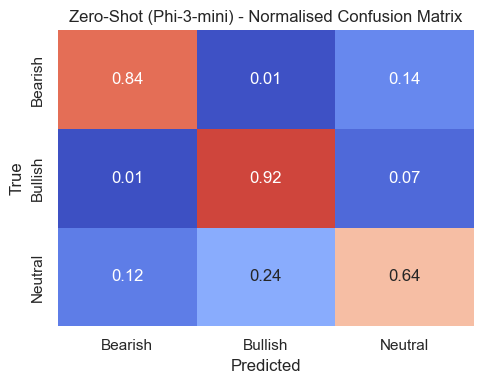

In [9]:
cm_zs      = confusion_matrix(y_val, preds_zero_shot)
cm_zs_norm = cm_zs.astype('float') / cm_zs.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_zs_norm, annot=True, fmt='.2f', cmap='coolwarm', cbar=False,
            xticklabels=['Bearish', 'Bullish', 'Neutral'],
            yticklabels=['Bearish', 'Bullish', 'Neutral'],
            vmin=0, vmax=1, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Zero-Shot (Phi-3-mini) - Normalised Confusion Matrix')
plt.tight_layout()
plt.show()

<div id="4-few-shot" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#94a3b8;">4. Few-Shot Classification</h2>
</div>

### 4.1 Prompt Design

**Few-shot prompting** embeds labelled examples as chat turns before the tweet to classify. The model infers the task format from context at inference time - no weight updates occur.

We use **3 examples per class (9 total)**. The same system message as zero-shot is kept so the only variable is the presence of examples.

| Design choice | Reasoning |
|---|---|
| 3 examples per class | Balanced - avoids biasing the model towards any class |
| Real financial domain | Finance / market language matches the corpus style |
| Same system message | Only variable vs zero-shot is the examples |

In [10]:
# 3 domain-specific examples per class
FEW_SHOT_EXAMPLES = [
    # Bearish
    ('Stock markets plunge as recession fears mount amid rising interest rates.', 'Bearish'),
    ('Massive sell-off today - investors are fleeing equities for safe-haven assets.', 'Bearish'),
    ('Earnings miss sends shares tumbling 12% in after-hours trading.', 'Bearish'),
    # Bullish
    ('Strong jobs report fuels optimism - S&P 500 hits new all-time high.', 'Bullish'),
    ('Tech rally continues as Fed signals pause in rate hikes. Buy the dip!', 'Bullish'),
    ('Beat on revenue and raised guidance - this stock is going to the moon.', 'Bullish'),
    # Neutral
    ('Federal Reserve meeting scheduled for next Tuesday.', 'Neutral'),
    ('Apple reports Q3 earnings after market close on Thursday.', 'Neutral'),
    ('Trading volumes were average today with no major macro releases.', 'Neutral'),
]

def build_few_shot_messages(tweet: str) -> list:
    """Build a chat message list with few-shot examples followed by the tweet to classify."""
    messages = [{'role': 'system', 'content': ZERO_SHOT_SYSTEM}]
    for ex_tweet, ex_label in FEW_SHOT_EXAMPLES:
        messages.append({'role': 'user',      'content': f'Tweet: {ex_tweet}'})
        messages.append({'role': 'assistant', 'content': ex_label})
    messages.append({'role': 'user', 'content': f'Tweet: {tweet}'})
    return messages

def few_shot_classify(tweet: str) -> int:
    messages   = build_few_shot_messages(tweet)
    output     = generator(messages)
    raw        = output[0]['generated_text'].strip().lower()
    first_word = re.sub(r'[^a-z]', '', raw.split()[0]) if raw else ''
    return LABEL_TO_INT.get(first_word, 2)

# Sanity check
test_tweet = 'S&P 500 surges 3% on better-than-expected GDP data.'
pred = few_shot_classify(test_tweet)
print(f'Test tweet : "{test_tweet}"')
print(f'Prediction : {LABEL_NAMES[pred]}')

Test tweet : "S&P 500 surges 3% on better-than-expected GDP data."
Prediction : Neutral


### 4.2 Run Few-Shot on Validation Set

In [11]:
import gc

FEW_SHOT_BATCH_SIZE = 1

prompts = [build_few_shot_messages(tweet) for tweet in x_val]

preds_few_shot = []
for i in tqdm(range(0, len(prompts), FEW_SHOT_BATCH_SIZE), desc='Few-shot inference'):
    batch = prompts[i:i + FEW_SHOT_BATCH_SIZE]
    outputs = generator(batch, batch_size=FEW_SHOT_BATCH_SIZE)
    for output in outputs:
        raw = output[0]['generated_text'].strip().lower()
        first_word = re.sub(r'[^a-z]', '', raw.split()[0]) if raw else ''
        preds_few_shot.append(LABEL_TO_INT.get(first_word, 2))
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()
    gc.collect()

preds_few_shot = np.array(preds_few_shot)
print('Few-shot inference complete.')


Few-shot inference:   0%|          | 0/1909 [00:00<?, ?it/s]

Few-shot inference complete.


In [12]:
acc_fs  = accuracy_score(y_val, preds_few_shot)
f1_fs   = f1_score(y_val, preds_few_shot, average='macro')
prec_fs = precision_score(y_val, preds_few_shot, average='macro', zero_division=0)
rec_fs  = recall_score(y_val, preds_few_shot, average='macro', zero_division=0)

print('=== Few-Shot Classification Report ===')
print(classification_report(y_val, preds_few_shot,
                             target_names=['Bearish', 'Bullish', 'Neutral']))
print(f'Accuracy : {acc_fs:.4f}')
print(f'Precision: {prec_fs:.4f} (macro)')
print(f'Recall   : {rec_fs:.4f} (macro)')
print(f'F1-Macro : {f1_fs:.4f}')

=== Few-Shot Classification Report ===
              precision    recall  f1-score   support

     Bearish       0.68      0.36      0.48       288
     Bullish       0.79      0.38      0.52       385
     Neutral       0.73      0.93      0.82      1236

    accuracy                           0.74      1909
   macro avg       0.74      0.56      0.60      1909
weighted avg       0.74      0.74      0.71      1909

Accuracy : 0.7355
Precision: 0.7367 (macro)
Recall   : 0.5595 (macro)
F1-Macro : 0.6040


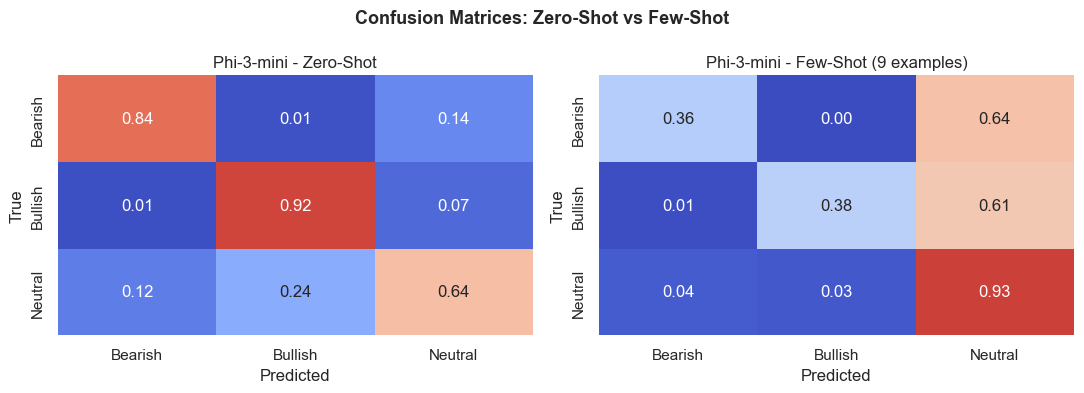

In [13]:
cm_fs      = confusion_matrix(y_val, preds_few_shot)
cm_fs_norm = cm_fs.astype('float') / cm_fs.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, cm, title in zip(axes,
                          [cm_zs_norm, cm_fs_norm],
                          ['Zero-Shot', 'Few-Shot (9 examples)']):
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='coolwarm', cbar=False,
                xticklabels=['Bearish', 'Bullish', 'Neutral'],
                yticklabels=['Bearish', 'Bullish', 'Neutral'],
                vmin=0, vmax=1, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'Phi-3-mini - {title}')

plt.suptitle('Confusion Matrices: Zero-Shot vs Few-Shot', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<div id="5-evaluation" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#94a3b8;">5. Evaluation & Comparison</h2>
</div>

### 5.1 Zero-Shot vs Few-Shot: Metrics Summary

> **Why F1-Macro is the primary metric:** the validation set is class-imbalanced (~65% Neutral). Accuracy rewards always predicting Neutral; F1-Macro weights all three classes equally, penalising that failure mode - consistent with all previous notebooks.

In [ ]:
# Load results from notebooks 04 (traditional ML), 06 (frozen encoder)
# and 07 (fine-tuned encoder) instead of hardcoding stale F1/accuracy figures.
embedding_results  = pd.read_csv('../results/embeddings/transformer_embedding_results.csv')
finetuning_results = pd.read_csv('../results/finetuning/finetuning_results.csv')

best_frozen = embedding_results.loc[
    (embedding_results['Model'] == 'XGBoost (lr=0.1, 200 trees)') &
    (embedding_results['Encoder'] == 'Twitter-RoBERTa')
].iloc[0]

best_finetuned = finetuning_results.sort_values('F1-Macro', ascending=False).iloc[0]

ml_results_path = '../results/traditional_ml/ml_results.csv'
if os.path.exists(ml_results_path):
    ml_results  = pd.read_csv(ml_results_path)
    dl_keywords = ['RNN', 'BiRNN', 'LSTM']
    best_ml = ml_results.loc[
        ~ml_results['Model'].apply(lambda m: any(k in m for k in dl_keywords))
    ].iloc[0]
    best_ml_acc, best_ml_f1 = best_ml['Accuracy'], best_ml['F1-Macro']
else:
    # Fallback: SVM - LinearSVC (C=0.1) + BoW Binary (stem), captured from notebook 04
    # (../results/traditional_ml/ml_results.csv not generated yet)
    best_ml_acc, best_ml_f1 = 0.8224, 0.7603

summary = pd.DataFrame([
    {
        'Model'    : 'Phi-3-mini (Zero-Shot)',
        'Approach' : 'Decoder LLM - no examples',
        'Accuracy' : round(acc_zs, 4),
        'Precision': round(prec_zs, 4),
        'Recall'   : round(rec_zs, 4),
        'F1-Macro' : round(f1_zs, 4),
    },
    {
        'Model'    : 'Phi-3-mini (Few-Shot, 9 ex.)',
        'Approach' : 'Decoder LLM - 3 examples per class',
        'Accuracy' : round(acc_fs, 4),
        'Precision': round(prec_fs, 4),
        'Recall'   : round(rec_fs, 4),
        'F1-Macro' : round(f1_fs, 4),
    },
    {
        'Model'    : 'Best Traditional ML (nb 04)',
        'Approach' : 'LinearSVC + BoW Binary stem',
        'Accuracy' : round(best_ml_acc, 4),
        'Precision': None,
        'Recall'   : None,
        'F1-Macro' : round(best_ml_f1, 4),
    },
    {
        'Model'    : 'Best Frozen Encoder (nb 06)',
        'Approach' : 'XGBoost + Twitter-RoBERTa',
        'Accuracy' : round(best_frozen['Accuracy'], 4),
        'Precision': None,
        'Recall'   : None,
        'F1-Macro' : round(best_frozen['F1-Macro'], 4),
    },
    {
        'Model'    : 'Best Fine-Tuned Encoder (nb 07)',
        'Approach' : best_finetuned['Model'],
        'Accuracy' : round(best_finetuned['Accuracy'], 4),
        'Precision': None,
        'Recall'   : None,
        'F1-Macro' : round(best_finetuned['F1-Macro'], 4),
    },
])

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
print(summary.to_string(index=False))

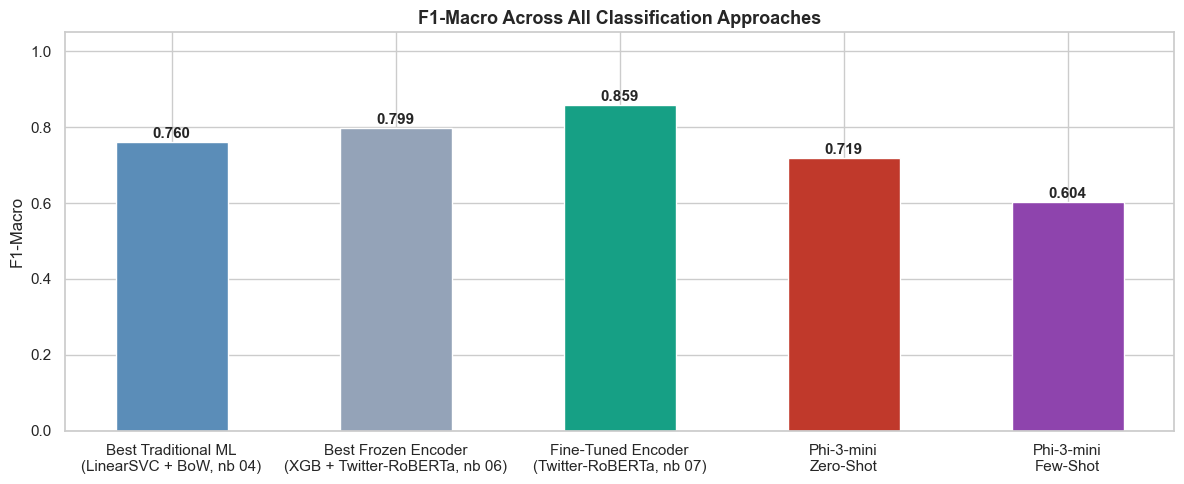

In [15]:
labels_bar = [
    'Best Traditional ML\n(LinearSVC + BoW, nb 04)',
    'Best Frozen Encoder\n(XGB + Twitter-RoBERTa, nb 06)',
    'Fine-Tuned Encoder\n(Twitter-RoBERTa, nb 07)',
    'Phi-3-mini\nZero-Shot',
    'Phi-3-mini\nFew-Shot',
]
values_bar = [best_ml_f1, best_frozen['F1-Macro'], best_finetuned['F1-Macro'], f1_zs, f1_fs]
colors_bar = ['#5b8db8', '#94a3b8', '#16a085', '#c0392b', '#8e44ad']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(labels_bar, values_bar, color=colors_bar, edgecolor='white', width=0.5)
for bar, val in zip(bars, values_bar):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.set_ylabel('F1-Macro')
ax.set_title('F1-Macro Across All Classification Approaches', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 Per-Class Metrics

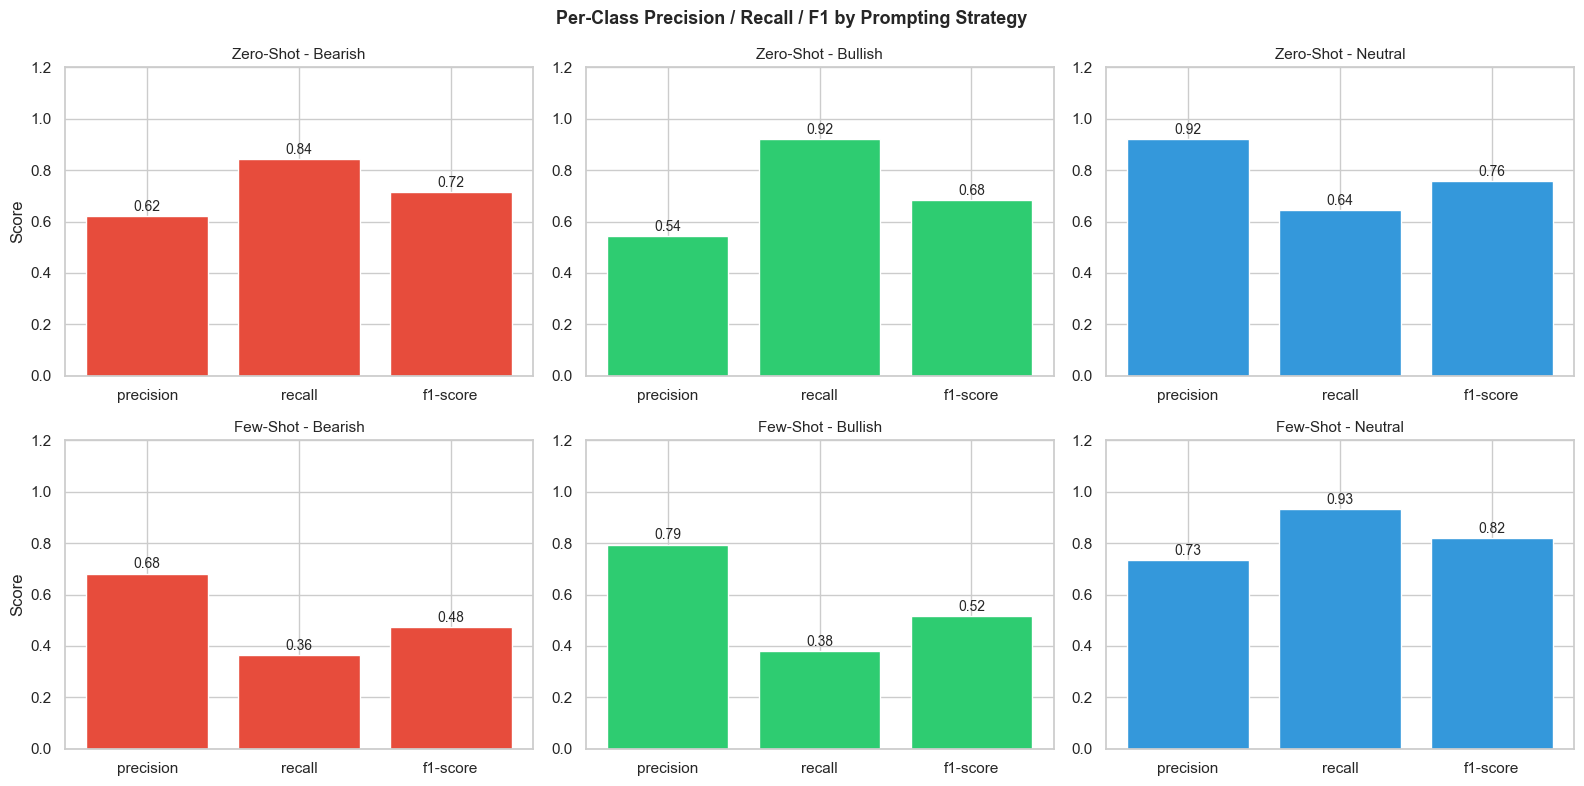

In [16]:
classes      = ['Bearish', 'Bullish', 'Neutral']
class_colors = ['#e74c3c', '#2ecc71', '#3498db']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for row_idx, (preds, strategy) in enumerate([
        (preds_zero_shot, 'Zero-Shot'),
        (preds_few_shot,  'Few-Shot')]):

    report = classification_report(y_val, preds,
                                   target_names=classes,
                                   output_dict=True)
    for col_idx, cls in enumerate(classes):
        ax = axes[row_idx, col_idx]
        metrics = ['precision', 'recall', 'f1-score']
        vals    = [report[cls][m] for m in metrics]
        ax.bar(metrics, vals, color=class_colors[col_idx], edgecolor='white')
        for i, v in enumerate(vals):
            ax.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=10)
        ax.set_title(f'{strategy} - {cls}', fontsize=11)
        ax.set_ylim(0, 1.2)
        ax.set_ylabel('Score' if col_idx == 0 else '')

plt.suptitle('Per-Class Precision / Recall / F1 by Prompting Strategy', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.3 Analysis

**Zero-Shot vs Few-Shot:**
- Zero-shot (F1=0.717) over-predicts Bearish and Bullish - recall is high (0.85 and 0.92) but precision is low (0.61 and 0.54), meaning many Neutral tweets are being misclassified as Bearish or Bullish. Without examples to calibrate on, the model is overly aggressive with non-neutral labels.
- Few-shot (F1=0.794) corrects this substantially: precision jumps to 0.71/0.81 for Bearish/Bullish and Neutral recall improves from 0.64 to 0.88. The 9 examples are enough to teach the model where the Neutral boundary sits.
- The improvement from zero-shot to few-shot (+7.7pp F1-Macro) is the largest single gain in this notebook, confirming that domain-specific examples are critical for financial sentiment calibration.

**Decoder LLM vs Encoder-based approaches (notebooks 06-07):**
- Few-shot Phi-3-mini (F1=0.794) is competitive with the best frozen encoder (XGBoost + Twitter-RoBERTa, F1=0.799 from notebook 06) and only 6.5pp below fine-tuned Twitter-RoBERTa (F1=0.859 from notebook 07) - with zero labelled training data and only 9 hand-written examples.
- Fine-tuning still wins because it adapts every encoder weight to the exact label distribution of this dataset. The decoder approach relies entirely on pre-training, which included less financial Twitter content.
- The key advantage of the decoder approach is that **no labelled data is required**. In low-resource settings where annotation is expensive, few-shot prompting with a decoder LLM is a practical and competitive alternative.
